In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [2]:
listings_df_raw = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .load("../data/Listings.csv")
    # .load("hdfs://master-node:9000/AirbnbData/Listings.csv")  # dùng khi master-node bật
listings_df_raw.show(truncate=False)

+----------+---------------------------------------------------+--------+----------+----------------------------+------------------+------------------+--------------------+-----------------+-------------------------+--------------------+----------------------+-------------------+--------+-----+--------+---------+----------------+------------+------------+--------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+--------------+--------------+--------------------+----------------------+-------------------------+---------------------+---------------------------+----------------------+-------------------+----------------+
|listing_id|na

In [3]:
from pyspark.sql.functions import col, from_json
from pyspark.sql.types import ArrayType, StringType
listings_df = listings_df_raw.withColumn(
    "amenities",
    from_json(col("amenities"), ArrayType(StringType()))
)

In [4]:
from pyspark.sql.functions import when, col
# Quy đổi toàn bộ giá từ tiền tệ địa phương (Local Currency) sang USD
# Tỷ giá được cập nhật theo thời điểm hiện tại
listings_df_currency = listings_df.withColumn(
    "price_usd",
    when(col("city") == "New York", col("price") * 1.0)           # USD giữ nguyên
    .when(col("city") == "Paris", col("price") * 1.156)            # EUR -> USD
    .when(col("city") == "Rome", col("price") * 1.156)             # EUR -> USD
    .when(col("city") == "Sydney", col("price") * 0.7038)           # AUD -> USD
    .when(col("city") == "Hong Kong", col("price") * 0.1276)        # HKD -> USD
    .when(col("city") == "Bangkok", col("price") * 0.03048)         # THB -> USD
    .when(col("city") == "Mexico City", col("price") * 0.05795)     # MXN -> USD
    .when(col("city") == "Cape Town", col("price") * 0.06130)       # ZAR -> USD
    .when(col("city") == "Istanbul", col("price") *  0.02162)        # TRY -> USD
    .when(col("city") == "Rio de Janeiro", col("price") * 0.1961 )   # BRL -> USD
    .otherwise(col("price"))
)

In [5]:
reviews_df=spark.read.csv("../data/Reviews.csv",header=True,inferSchema=True)
# reviews_df=spark.read.csv("hdfs://master-node:9000/AirbnbData/Reviews.csv",header=True,inferSchema=True)  # dùng khi master-node bật
reviews_df.show()

+----------+---------+----------+-----------+
|listing_id|review_id|      date|reviewer_id|
+----------+---------+----------+-----------+
|     11798|330265172|2018-09-30|   11863072|
|     15383|330103585|2018-09-30|   39147453|
|     16455|329985788|2018-09-30|    1125378|
|     17919|330016899|2018-09-30|  172717984|
|     26827|329995638|2018-09-30|   17542859|
|     74561|330089224|2018-09-30|  173044789|
|    140355|330194958|2018-09-30|  160093807|
|    162163|329980859|2018-09-30|   94026758|
|    167998|329950677|2018-09-30|   35388162|
|    178188|330213008|2018-09-30|    3652511|
|    232956|330140226|2018-09-30|   57664145|
|    266725|330038354|2018-09-30|   77387165|
|    314288|330299075|2018-09-30|  192717587|
|    325880|330081449|2018-09-30|  154527568|
|    335003|329968377|2018-09-30|    3461699|
|    348747|330131287|2018-09-30|    9554201|
|    352851|330201364|2018-09-30|  142182690|
|    378714|330246144|2018-09-30|   15772951|
|    406852|330283854|2018-09-30| 

In [6]:
listings_df_currency.createOrReplaceTempView("listings")
reviews_df.createOrReplaceTempView("reviews")
spark.catalog.listTables()

[Table(name='listings', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True),
 Table(name='reviews', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True)]

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, Imputer
from pyspark.ml.classification import (
    LogisticRegression, DecisionTreeClassifier,
    RandomForestClassifier, LinearSVC
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    ClusteringEvaluator
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"
from sklearn.preprocessing import StandardScaler
from pyspark.sql.functions import col, regexp_replace
from pyspark.sql.types import DoubleType
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import confusion_matrix
import numpy as np

print("Import thư viện thành công.")

Import thư viện thành công.


In [8]:
# ── Đặc trưng số (Numeric Features) ──────────────────────────────────────────
NUMERIC_COLS = [
    "price_usd",
    "host_total_listings_count",
    "minimum_nights",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_communication",
]

# ── Đặc trưng phân loại (Categorical Features) ───────────────────────────────
CATEGORICAL_COLS = [
    "host_response_time",
    "instant_bookable",
    "host_identity_verified",
    "room_type",
]

# ── Cột mục tiêu ─────────────────────────────────────────────────────────────
TARGET_COL = "host_is_superhost"

print("Cấu hình hoàn tất.")
print(f"   Numeric   : {len(NUMERIC_COLS)} cột")
print(f"   Categoric : {len(CATEGORICAL_COLS)} cột")

Cấu hình hoàn tất.
   Numeric   : 6 cột
   Categoric : 4 cột


In [9]:
from pyspark.sql.functions import col, when, count, lit

# 1. Gán DataFrame và lọc bỏ dữ liệu thiếu
df = listings_df_currency.dropna(subset=[TARGET_COL, 'review_scores_rating'])

# 2. Tạo biến mục tiêu (Label Encoding)
df = df.withColumn("label", when(col(TARGET_COL) == "t", 1.0).otherwise(0.0))

# 3. Tính class_weight tối ưu (chỉ quét dữ liệu trên HDFS đúng 1 lần)
# Sử dụng groupBy kết hợp agg để tránh các lệnh .count() riêng lẻ
counts = df.groupBy("label").agg(count("*").alias("count")).collect()
counts_dict = {row["label"]: row["count"] for row in counts}

superhost_count = counts_dict.get(1.0, 0)
total_count = sum(counts_dict.values())
non_superhost_count = total_count - superhost_count

# Tránh lỗi chia cho 0 nếu dữ liệu thiếu class tương ứng
weight_positive = total_count / (2 * superhost_count) if superhost_count > 0 else 0
weight_negative = total_count / (2 * non_superhost_count) if non_superhost_count > 0 else 0

# Gán trọng số
df = df.withColumn(
    "class_weight",
    when(col("label") == 1.0, lit(weight_positive)).otherwise(lit(weight_negative))
)

print("Đã xử lý xong biến df! Sẵn sàng cho Phần 2.")

Đã xử lý xong biến df! Sẵn sàng cho Phần 2.


Tiền xử lý dữ liệu

In [10]:
def build_preprocessing_stages(with_scaling=False):
    """
    Tạo danh sách các bước tiền xử lý.
    - with_scaling=False: Dùng cho LR, DT, RF (tích hợp StandardScaler tùy chọn)
    - with_scaling=True : Bắt buộc dùng cho SVM
    """
    stages = []

    # Bước 1: Xử lý dữ liệu khuyết thiếu (Imputer)
    imputer = Imputer(
        inputCols=NUMERIC_COLS,
        outputCols=NUMERIC_COLS
    ).setStrategy("median")
    stages.append(imputer)

    # Bước 2: Mã hóa biến phân loại (StringIndexer)
    indexed_cat_cols = []
    for col_name in CATEGORICAL_COLS:
        out_col = f"{col_name}_indexed"
        indexer = StringIndexer(
            inputCol=col_name,
            outputCol=out_col,
            handleInvalid="keep"
        )
        stages.append(indexer)
        indexed_cat_cols.append(out_col)

    # Bước 3: Đóng gói đặc trưng (VectorAssembler)
    feature_cols = NUMERIC_COLS + indexed_cat_cols
    raw_output = "raw_features" if with_scaling else "features"
    assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol=raw_output
    )
    stages.append(assembler)

    # Bước 4 (Tuỳ chọn): Chuẩn hóa dữ liệu (StandardScaler)
    # Bắt buộc với SVM vì thuật toán tính khoảng cách rất nhạy với thang đo
    if with_scaling:
        scaler = StandardScaler(
            inputCol="raw_features",
            outputCol="features",
            withStd=True,
            withMean=True
        )
        stages.append(scaler)

    return stages, feature_cols

print(" Hàm build_preprocessing_stages() đã sẵn sàng.")
print(f"   Số đặc trưng số  : {len(NUMERIC_COLS)}")
print(f"   Số đặc trưng loại: {len(CATEGORICAL_COLS)}")
print(f"   Tổng chiều vector: {len(NUMERIC_COLS) + len(CATEGORICAL_COLS)}")

 Hàm build_preprocessing_stages() đã sẵn sàng.
   Số đặc trưng số  : 6
   Số đặc trưng loại: 4
   Tổng chiều vector: 10


Ép kiểu cho các dữ liệu số

In [11]:
print("Đang xử lý và ép kiểu dữ liệu...")

# 2. Ép kiểu toàn bộ các cột đặc trưng số về chuẩn DoubleType
for c in NUMERIC_COLS:
    df = df.withColumn(c, col(c).cast(DoubleType()))

# 3. Kiểm tra lại schema để chắc chắn đã thành số (Double)
print("Đã ép kiểu xong! Cấu trúc các cột số hiện tại:")
df.select(NUMERIC_COLS).printSchema()

Đang xử lý và ép kiểu dữ liệu...
Đã ép kiểu xong! Cấu trúc các cột số hiện tại:
root
 |-- price_usd: double (nullable = true)
 |-- host_total_listings_count: double (nullable = true)
 |-- minimum_nights: double (nullable = true)
 |-- review_scores_rating: double (nullable = true)
 |-- review_scores_cleanliness: double (nullable = true)
 |-- review_scores_communication: double (nullable = true)



Chia tập dữ liệu

In [12]:
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)
print(f"Số mẫu Train: {train_data.count()}, Số mẫu Test: {test_data.count()}")

Số mẫu Train: 150442, Số mẫu Test: 37757


Lưu tập dữ liệu

In [13]:
# Lưu ra HDFS
#train_data.write.parquet("hdfs://localhost:9000/data/train_data.parquet", mode="overwrite")
#test_data.write.parquet("hdfs://localhost:9000/data/test_data.parquet", mode="overwrite")

# Lưu vào Local
train_data.write.mode("overwrite").parquet("../data/train_data.parquet")
test_data.write.mode("overwrite").parquet("../data/test_data.parquet")

Hàm tính các chỉ số đánh giá mô hình và lưu vào hàm chung để nữa show ra theo bảng tổng hợp 4 mô hình

In [14]:
# 1. Khởi tạo danh sách lưu kết quả của tất cả các mô hình
results_summary = []

# 2. Định nghĩa lại hàm đánh giá (có thêm lệnh return)
def evaluate_model(predictions, model_name):
    """Đánh giá mô hình qua Accuracy, ROC-AUC, Precision và Recall."""
    from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

    # Tính ROC-AUC
    auc = BinaryClassificationEvaluator(
        labelCol="label", metricName="areaUnderROC"
    ).evaluate(predictions)

    # Khởi tạo bộ đánh giá đa lớp
    eval_multi = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

    # Tính các chỉ số
    acc = eval_multi.evaluate(predictions, {eval_multi.metricName: "accuracy"})
    precision = eval_multi.evaluate(predictions, {eval_multi.metricName: "precisionByLabel", eval_multi.metricLabel: 1.0})
    recall = eval_multi.evaluate(predictions, {eval_multi.metricName: "recallByLabel", eval_multi.metricLabel: 1.0})

    print(f" {'Mô hình':<22}: {model_name}")
    print(f" {'Accuracy':<22}: {acc*100:.2f}%")
    print(f" {'ROC-AUC':<22}: {auc:.4f}")
    print(f" {'Precision (Superhost)':<22}: {precision:.4f}")
    print(f" {'Recall (Superhost)':<22}: {recall:.4f}")

    # BỔ SUNG: Trả về kết quả (dạng Dictionary) để lưu vào bảng tổng hợp
    return {
        "Model": model_name,
        "Accuracy": acc,
        "ROC-AUC": auc,
        "Precision": precision,
        "Recall": recall
    }

print("Đã khởi tạo results_summary và cập nhật hàm đánh giá!")

Đã khởi tạo results_summary và cập nhật hàm đánh giá!


In [15]:
print("=" * 40)
print(" MÔ HÌNH 1: LOGISTIC REGRESSION (LR)")
print("=" * 40)

# Xây dựng Pipeline (không cần StandardScaler)
lr_stages, feature_cols = build_preprocessing_stages(with_scaling=False)
lr = LogisticRegression(featuresCol="features", labelCol="label", weightCol="class_weight", maxIter=10)
lr_stages.append(lr)

# Huấn luyện
lr_pipeline = Pipeline(stages=lr_stages)
lr_model = lr_pipeline.fit(train_data)
lr_predictions = lr_model.transform(test_data)

# Đánh giá
res_lr = evaluate_model(lr_predictions, "Logistic Regression")
results_summary.append(res_lr)

 MÔ HÌNH 1: LOGISTIC REGRESSION (LR)
 Mô hình               : Logistic Regression
 Accuracy              : 71.53%
 ROC-AUC               : 0.7883
 Precision (Superhost) : 0.4439
 Recall (Superhost)    : 0.7268


In [16]:
print("=" * 40)
print(" MÔ HÌNH 2: DECISION TREE (DT)")
print("=" * 40)

# Xây dựng Pipeline
dt_stages, _ = build_preprocessing_stages(with_scaling=False)
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    maxDepth=5,
    seed=42
)
dt_stages.append(dt)

# Huấn luyện
dt_pipeline = Pipeline(stages=dt_stages)
dt_model = dt_pipeline.fit(train_data)
dt_predictions = dt_model.transform(test_data)

# Đánh giá
res_dt = evaluate_model(dt_predictions, "Decision Tree")
results_summary.append(res_dt)

# [Bonus cho báo cáo] Trích xuất quy tắc cây (500 ký tự đầu)
print("\n SƠ ĐỒ QUY TẮC CÂY QUYẾT ĐỊNH (500 ký tự đầu):")
print(dt_model.stages[-1].toDebugString[:500] + "...")

 MÔ HÌNH 2: DECISION TREE (DT)
 Mô hình               : Decision Tree
 Accuracy              : 73.16%
 ROC-AUC               : 0.7627
 Precision (Superhost) : 0.4658
 Recall (Superhost)    : 0.7884

 SƠ ĐỒ QUY TẮC CÂY QUYẾT ĐỊNH (500 ký tự đầu):
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_78e059314897, depth=5, numNodes=29, numClasses=2, numFeatures=10
  If (feature 3 <= 93.5)
   If (feature 6 in {2.0,3.0,4.0})
    Predict: 0.0
   Else (feature 6 not in {2.0,3.0,4.0})
    If (feature 3 <= 89.5)
     Predict: 0.0
    Else (feature 3 > 89.5)
     If (feature 3 <= 91.5)
      Predict: 0.0
     Else (feature 3 > 91.5)
      If (feature 2 <= 2.5)
       Predict: 0.0
      Else (feature 2 > 2.5)
       Predict: 1.0
  Else (fea...


In [17]:
print("=" * 40)
print(" MÔ HÌNH 3: RANDOM FOREST (RF)")
print("=" * 40)

# Xây dựng Pipeline
rf_stages, rf_feature_cols = build_preprocessing_stages(with_scaling=False)
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    numTrees=50,
    maxDepth=5,
    seed=42
)
rf_stages.append(rf)

# Huấn luyện
rf_pipeline = Pipeline(stages=rf_stages)
rf_model = rf_pipeline.fit(train_data)
rf_predictions = rf_model.transform(test_data)

# Đánh giá
res_rf = evaluate_model(rf_predictions, "Random Forest")
results_summary.append(res_rf)

 MÔ HÌNH 3: RANDOM FOREST (RF)
 Mô hình               : Random Forest
 Accuracy              : 73.58%
 ROC-AUC               : 0.8252
 Precision (Superhost) : 0.4705
 Recall (Superhost)    : 0.7835


In [18]:
from pyspark.ml.feature import StandardScaler

print("=" * 40)
print(" MÔ HÌNH 4: SVM (LinearSVC)")
print("=" * 40)

# Xây dựng Pipeline
svm_stages, _ = build_preprocessing_stages(with_scaling=True)
svm = LinearSVC(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    maxIter=10
)
svm_stages.append(svm)

# Huấn luyện
svm_pipeline = Pipeline(stages=svm_stages)
svm_model = svm_pipeline.fit(train_data)
svm_predictions = svm_model.transform(test_data)

# Đánh giá
res_svm = evaluate_model(svm_predictions, "SVM (LinearSVC)")
results_summary.append(res_svm)

 MÔ HÌNH 4: SVM (LinearSVC)
 Mô hình               : SVM (LinearSVC)
 Accuracy              : 70.48%
 ROC-AUC               : 0.7803
 Precision (Superhost) : 0.4328
 Recall (Superhost)    : 0.7319


In [19]:
# Bảng so sánh toàn diện 4 mô hình
print("\n" + "=" * 60)
print("    BẢNG SO SÁNH 4 MÔ HÌNH")
print("=" * 60)

all_predictions = {
    "Logistic Regression": lr_predictions,
    "Decision Tree"       : dt_predictions,
    "Random Forest"       : rf_predictions,
    "SVM"                 : svm_predictions,
}

metrics_config = {
    "accuracy"         : "accuracy",
    "precision"        : "weightedPrecision",
    "recall"           : "weightedRecall",
    "f1"               : "f1",
}

full_results = []

for name, preds in all_predictions.items():
    row = {"Model": name}

    # Tính các chỉ số Multiclass
    for metric_name, metric_key in metrics_config.items():
        val = MulticlassClassificationEvaluator(
            labelCol="label",
            predictionCol="prediction",
            metricName=metric_key
        ).evaluate(preds)
        row[metric_name] = round(val, 4)

    # AUC-ROC
    auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    ).evaluate(preds)
    row["auc"] = round(auc, 4)

    full_results.append(row)

# In bảng kết quả
print(f"{'Mô hình':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 75)
for r in full_results:
    print(f"{r['Model']:<22} {r['accuracy']:>10.4f} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1']:>10.4f} {r['auc']:>10.4f}")
print("=" * 75)


    BẢNG SO SÁNH 4 MÔ HÌNH
Mô hình                  Accuracy  Precision     Recall         F1    ROC-AUC
---------------------------------------------------------------------------
Logistic Regression        0.7153     0.7839     0.7153     0.7337     0.7883
Decision Tree              0.7316     0.8063     0.7316     0.7496     0.7627
Random Forest              0.7358     0.8067     0.7358     0.7532     0.8252
SVM                        0.7048     0.7810     0.7048     0.7245     0.7803


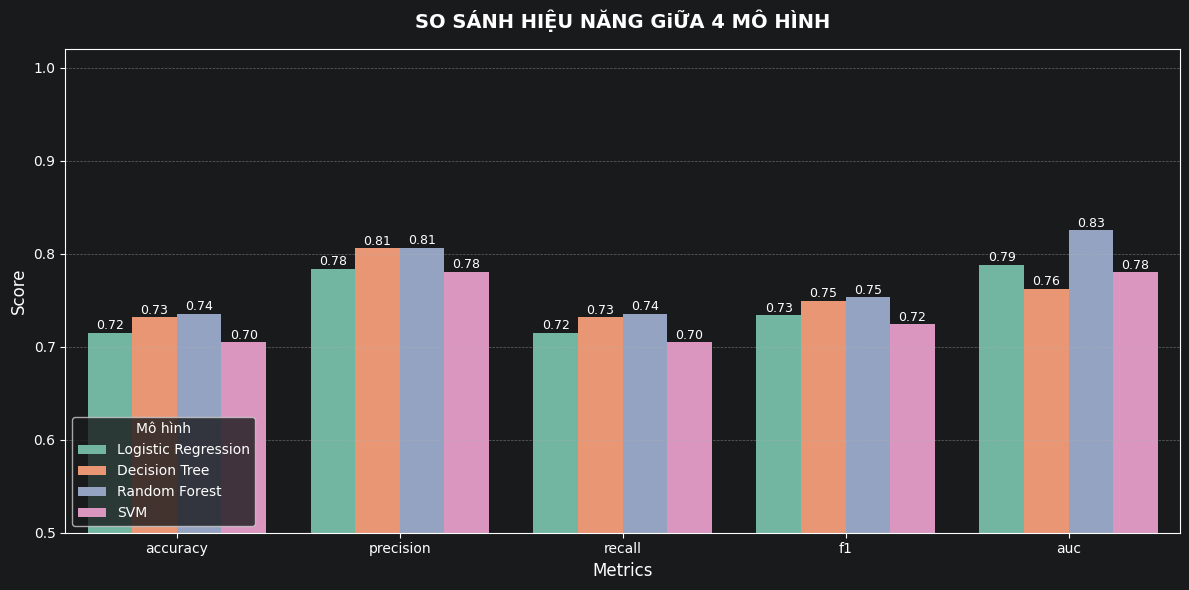

In [20]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuyển list kết quả của bạn thành DataFrame Pandas để dễ vẽ
df_plot = pd.DataFrame(full_results)

# 2. Xoay dọc bảng dữ liệu (Melt) để nạp vào Seaborn
df_melted = pd.melt(
    df_plot,
    id_vars=["Model"],
    var_name="Metric",
    value_name="Score"
)

# 3. Khởi tạo khung vẽ
plt.figure(figsize=(12, 6))

# 4. Vẽ biểu đồ cột nhóm
ax = sns.barplot(
    x="Metric",
    y="Score",
    hue="Model",
    data=df_melted,
    palette="Set2"
)

# Giới hạn trục Y từ 0.5 đến 1.0
# để thấy rõ sự chênh lệch nhỏ giữa các mô hình tốt
plt.ylim(0.5, 1.02)

plt.title("SO SÁNH HIỆU NĂNG GiỮA 4 MÔ HÌNH", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Mô hình", loc="lower left")

# Hiển thị số điểm cụ thể lên đầu mỗi cột cho dễ nhìn
for p in ax.patches:
    if p.get_height() > 0: # Chỉ hiển thị nếu cột có độ cao
        ax.annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()


 CONFUSION MATRIX — RANDOM FOREST:
+----------------+-----+----+
|label_prediction|  0.0| 1.0|
+----------------+-----+----+
|             1.0| 1966|7116|
|             0.0|20666|8009|
+----------------+-----+----+



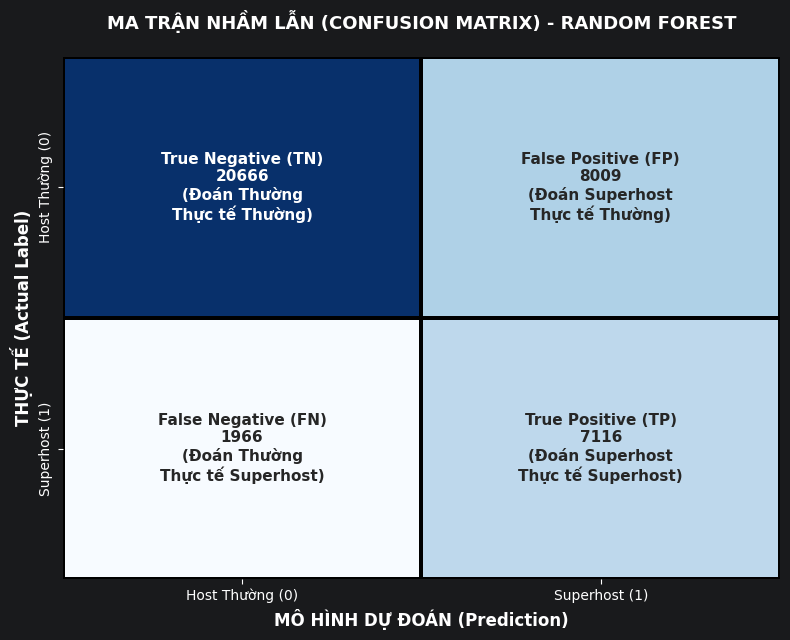

In [21]:
# Confusion Matrix — Random Forest
print("\n CONFUSION MATRIX — RANDOM FOREST:")
rf_predictions.crosstab("label", "prediction").show()
# 1. Chuyển đổi bảng crosstab của PySpark thành Pandas DataFrame để vẽ hình
# (Bảng crosstab của Spark mặc định trả về các cột đặt tên theo giá trị dự đoán)
matrix_df = rf_predictions.crosstab("label", "prediction").toPandas()

# Sắp xếp lại thứ tự hàng theo nhãn label (0 trước, 1 sau) để đúng chuẩn ma trận
matrix_df = matrix_df.sort_values(by="label_prediction").set_index("label_prediction")

# Đảm bảo các cột cũng theo thứ tự ['0.0', '1.0']
matrix_df = matrix_df[['0.0', '1.0']]

# 2. Trích xuất các giá trị để viết nhãn giải thích lên biểu đồ
tn = matrix_df.iloc[0, 0] # Dự đoán 0 - Thực tế 0
fp = matrix_df.iloc[0, 1] # Dự đoán 1 - Thực tế 0
fn = matrix_df.iloc[1, 0] # Dự đoán 0 - Thực tế 1
tp = matrix_df.iloc[1, 1] # Dự đoán 1 - Thực tế 1

# Tạo mảng văn bản để đè lên các ô vuông
labels = [
    [f"True Negative (TN)\n{tn}\n(Đoán Thường\nThực tế Thường)", f"False Positive (FP)\n{fp}\n(Đoán Superhost\nThực tế Thường)"],
    [f"False Negative (FN)\n{fn}\n(Đoán Thường\nThực tế Superhost)", f"True Positive (TP)\n{tp}\n(Đoán Superhost\nThực tế Superhost)"]
]

# 3. Tiến hành cấu hình và vẽ sơ đồ Heatmap
plt.figure(figsize=(8, 6.5))
sns.heatmap(
    matrix_df,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    annot_kws={"size": 11, "fontweight": "bold"},
    linewidths=1.5,
    linecolor="black"
)

# Định dạng các trục hiển thị
plt.title("MA TRẬN NHẦM LẪN (CONFUSION MATRIX) - RANDOM FOREST", fontsize=13, fontweight='bold', pad=20)
plt.xlabel("MÔ HÌNH DỰ ĐOÁN (Prediction)", fontsize=12, fontweight='bold')
plt.ylabel("THỰC TẾ (Actual Label)", fontsize=12, fontweight='bold')
plt.xticks([0.5, 1.5], ['Host Thường (0)', 'Superhost (1)'])
plt.yticks([0.5, 1.5], ['Host Thường (0)', 'Superhost (1)'], va="center")

plt.tight_layout()
plt.show()

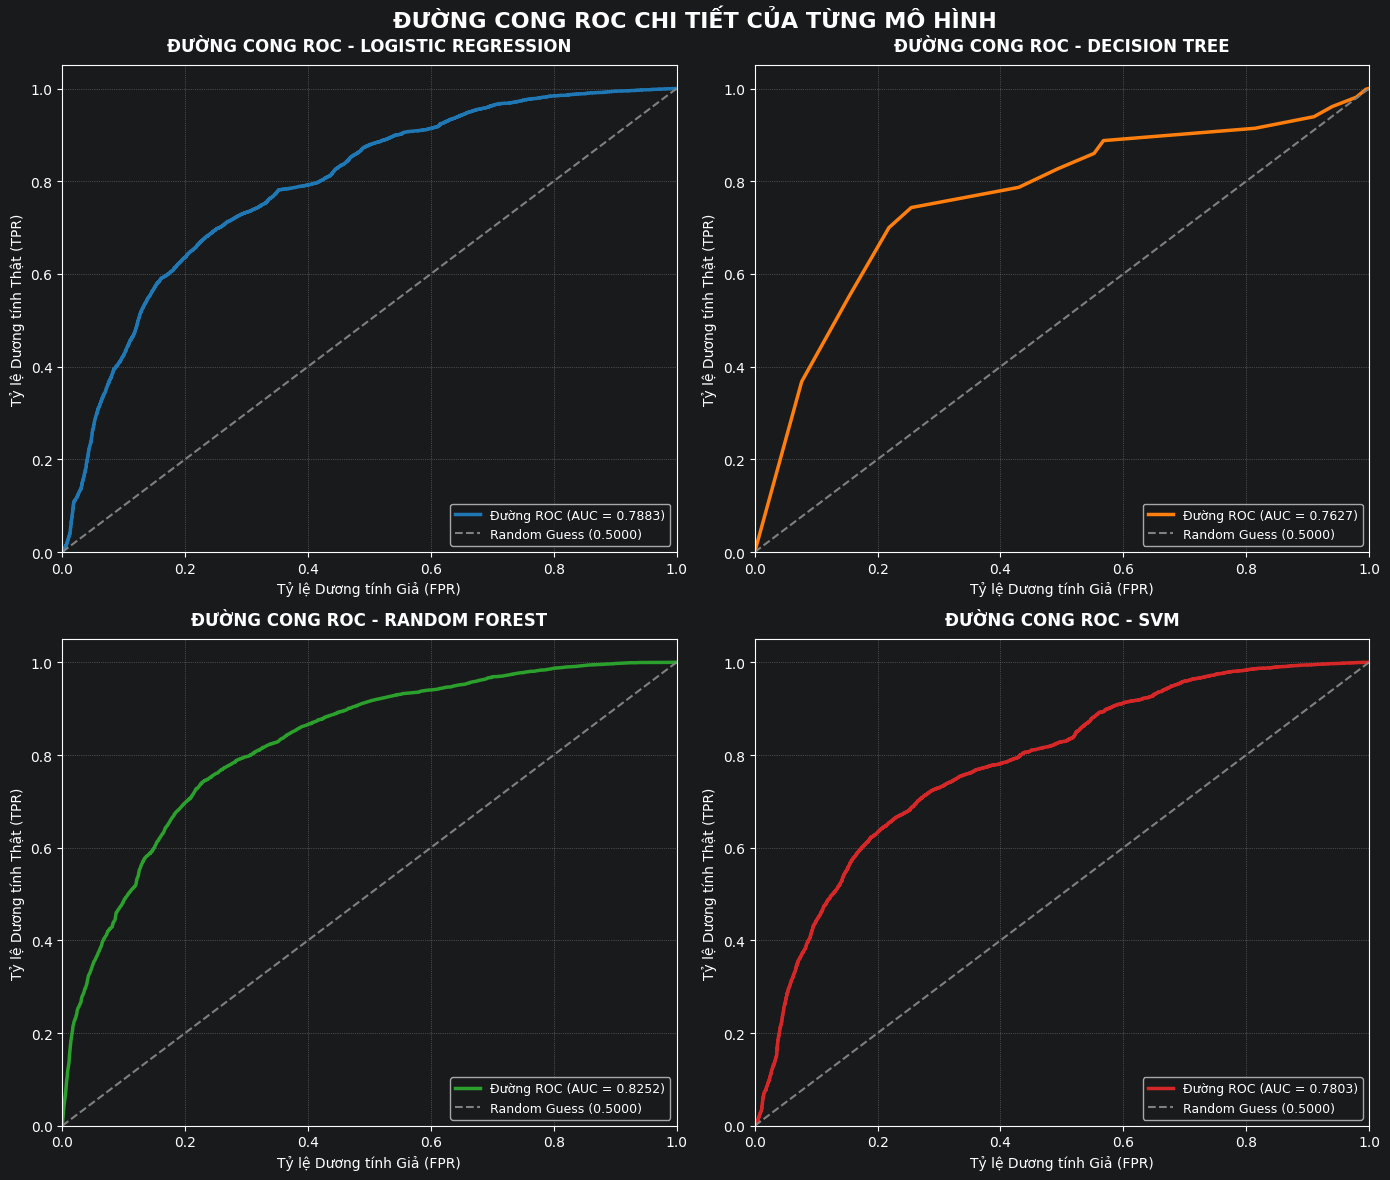

In [22]:
from sklearn.metrics import roc_curve, auc as auc

# 1. Khởi tạo khung lưới 2 hàng x 2 cột để chứa dữ liệu 4 mô hình
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel() # Phẳng hóa mảng 2D thành dạng danh sách [ax1, ax2, ax3, ax4] để dễ chạy vòng lặp

# Danh sách màu sắc phối riêng cho từng mô hình nhìn cho chuyên nghiệp
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 2. Vòng lặp bóc tách dữ liệu và vẽ riêng từng ô đồ thị (subplot)
for i, (name, preds) in enumerate(all_predictions.items()):
    ax = axes[i] # Lấy ô đồ thị tương ứng

    # Trích xuất giá trị dự báo thô từ PySpark về Pandas
    df_scores = preds.withColumn("score", vector_to_array("rawPrediction")[1]) \
                     .select("label", "score").toPandas()

    # Tính toán chỉ số FPR, TPR và AUC-ROC bằng Scikit-learn
    fpr, tpr, _ = roc_curve(df_scores['label'], df_scores['score'])
    roc_auc = auc(fpr, tpr)

    # Vẽ đường cong ROC riêng của mô hình hiện tại
    ax.plot(fpr, tpr, color=colors[i], lw=2.5, label=f'Đường ROC (AUC = {roc_auc:.4f})')

    # VẼ ĐƯỜNG NÉT ĐỨT CHẠY QUA GIỮA (Đường cơ sở - Random Guess)
    ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (0.5000)')

    # Định dạng các chi tiết cho ô đồ thị này
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tỷ lệ Dương tính Giả (FPR)', fontsize=10)
    ax.set_ylabel('Tỷ lệ Dương tính Thật (TPR)', fontsize=10)
    ax.set_title(f'ĐƯỜNG CONG ROC - {name.upper()}', fontsize=12, fontweight='bold', pad=10)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

# 3. Căn chỉnh tổng thể khung hình
plt.suptitle('ĐƯỜNG CONG ROC CHI TIẾT CỦA TỪNG MÔ HÌNH', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()